In [118]:
# Nulll/Missing values for each municipallity time series see if any timestamp is missing.
# See waht municipality has Null energy values 
# Consumos negativos foram apagadoos coomoo faer?
# Consumo medio diario
# coonsumo diario top5 menos consumo dias plot
# Consumo semanal 
# Coonsumo Diario 
# Autocorrelação ACF n PACF 
# Stationary?
# Seosonal Decomp?
# Save plot sinto plot folder 

# Notebook 2 — Exploratory Data Analysis & Feature Engineering
## E-Redes Hourly Electricity Consumption by Municipality

---

## Notebook Overview

This notebook takes the cleaned, municipality-enriched dataset produced in **Notebook 1** and performs a thorough exploratory analysis to:

- Understand the **structure and quality** of the data (nulls, coverage, balance)
- Identify **temporal patterns** — hourly, daily, and weekly consumption profiles
- Identify **geographic patterns** — which municipalities consume most and least
- Detect **anomalies** — unusual spikes or drops in consumption
- Engineer **features** for use in the ML forecasting model (Notebook 3)

### Key questions we aim to answer

| Question | Analysis |
|----------|----------|
| What does a typical day of consumption look like? | Hourly profile plot || Which municipalities consume the most / least? | Geographic ranking |
| Does consumption differ on weekends vs weekdays? | Segmented comparison |
| Are there anomalous spikes in the time series? | Z-score outlier detection |
| Is the time series stationary? | ADF test |
| What temporal features matter most for forecasting? | ACF / PACF analysis |

### Approach
All aggregations and transformations are performed in **Spark** (big-data-safe). 
Only the final, small aggregated results are converted to Pandas for visualisation — 
with explicit comments explaining this pattern.

### Purpose
The main purpose of this notebook is to showcase Spark's core analytical capabilities 
across three layers:

1. **Spark SQL** — registering DataFrames as temporary views and querying them with 
   standard SQL, demonstrating that Spark can serve as a distributed SQL engine over 
   large datasets without loading data into memory.

2. **DataFrame API** — chained transformations, window functions, and aggregations 
   using `pyspark.sql.functions`, showing the programmatic alternative to SQL with 
   the same distributed execution guarantees.

3. **Spark UI & Execution Plans** — using `.explain()` to inspect the Catalyst 
   optimizer's query plan, demonstrating how Spark optimizes operations like predicate 
   pushdown, broadcast joins, and partition pruning under the hood.

The notebook follows a consistent pattern throughout:
- **Spark** handles all heavy lifting on the full dataset
- **Pandas** is used only at the final step for plotting, on small aggregated results
- Every `.toPandas()` call is explicitly justified with a comment explaining why 
  it is safe at that point

---
## 1. Environment Setup

In [119]:
import sys
import os

import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, TimestampType, IntegerType
from pyspark.sql.window import Window

import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"]    = 100

# Output folders
PLOT_DIR = "code/plots/"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"PySpark version: {pyspark.__version__}")
print(f"Python version:  {sys.version.split('|')[0].strip()}")
print(f"Plots will be saved to: {os.path.abspath(PLOT_DIR)}")

PySpark version: 3.5.0
Python version:  3.11.6
Plots will be saved to: /home/jovyan/code/plots


In [120]:
# SparkSession — getOrCreate() reuses the session from Notebook 1 if still
# alive in the same kernel, otherwise starts a fresh one.


spark = (
    SparkSession.builder
    .appName("bda_eredes_eda")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", 6)
    .config("spark.sql.repl.eagereval.enabled", True)
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

spark

In [121]:
# Path configuration — all paths centralised here for easy environment changes


DATA_DIR       = "code/data/"
DATA_PROCESSED = DATA_DIR + "processed/"
DATA_MODEL     = DATA_DIR + "model_input/"

EREDES_PARQUET     = DATA_PROCESSED + "eredes_clean.parquet"
MODEL_INPUT_PARQUET = DATA_MODEL    + "model_input.parquet"

os.makedirs(DATA_MODEL, exist_ok=True)

print(f"Input:  {EREDES_PARQUET}")
print(f"Output: {MODEL_INPUT_PARQUET}")

Input:  code/data/processed/eredes_clean.parquet
Output: code/data/model_input/model_input.parquet


---
## 2. Load Data

In [122]:
# Load the cleaned Parquet produced by Notebook 1
df = spark.read.parquet(EREDES_PARQUET)

# Register as a SQL view so we can use spark.sql() throughout the notebook.
# NOTE: createOrReplaceTempView() is lazy — it does not trigger any computation.
# The view is only materialised when a query runs against it.
df.createOrReplaceTempView("eredes")

print("Schema:")
df.printSchema()

print(f"\nTotal rows: {df.count():,}")
print("\nSample rows:")

df.cache()
df.show(5, truncate=False)

Schema:
root
 |-- municipality: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- total_active_energy_kwh: double (nullable = true)
 |-- year_month: string (nullable = true)


Total rows: 2,228,170

Sample rows:
+---------------+-------------------+-----------------------+----------+
|municipality   |datetime           |total_active_energy_kwh|year_month|
+---------------+-------------------+-----------------------+----------+
|peniche        |2022-12-01 00:00:00|9723.999598886292      |2022-12   |
|nelas          |2022-12-01 00:00:00|23449.73224200879      |2022-12   |
|torres novas   |2022-12-01 01:00:00|19766.59265957604      |2022-12   |
|montemor-o-novo|2022-12-01 01:00:00|6971.904642924731      |2022-12   |
|marvão         |2022-12-01 01:00:00|968.6271428030009      |2022-12   |
+---------------+-------------------+-----------------------+----------+
only showing top 5 rows



---
## 3. Data Quality Assessment

Before any analysis we validate the dataset against the questions raised in Notebook 1:
- Are all municipalities represented equally across time? All municipalities should have the same number of records? 
- How many rows have null municipality or null energy values? 
- Are there gaps in the hourly time series? If there are how should we impute them?

In [123]:
#group twice:
#   First pass:  count observations per municipality
#   Second pass: count how many municipalities share each observation count
# A balanced dataset produces a single row in the second result.


obs_per_municipality = df.groupBy("municipality").count()

print("Distribution of observation counts across municipalities:")
obs_per_municipality \
    .groupBy("count") \
    .agg(F.count("*").alias("n_municipalities")) \
    .withColumnRenamed("count", "n_observations") \
    .orderBy("n_observations") \
    .show()

Distribution of observation counts across municipalities:
+--------------+----------------+
|n_observations|n_municipalities|
+--------------+----------------+
|          8015|             278|
+--------------+----------------+



In [124]:
# 3.2 Null audit — single Spark pass across all columns.
# We build a single aggregation expression for all columns to avoid
# triggering one Spark job per column, which would be inefficient at scale.

null_counts = df.select([
    F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)) if df.schema[c].dataType.typeName() in ['double', 'float'] 
                   else F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

print("Null / NaN counts per column:")
null_counts.show(truncate=False)

Null / NaN counts per column:
+------------+--------+-----------------------+----------+
|municipality|datetime|total_active_energy_kwh|year_month|
+------------+--------+-----------------------+----------+
|0           |0       |0                      |0         |
+------------+--------+-----------------------+----------+



In [125]:
# We already know OUTROS postal codes were not mapped to a municipality
# during the spatial join in Notebook 1 — those rows have null municipality
# and were filtered out in section 3.5. 

spark.sql("""
    SELECT
        municipality,
        COUNT(*)                                            AS total_rows,
        COUNT(total_active_energy_kwh)                     AS non_null_energy,
        SUM(CASE WHEN total_active_energy_kwh IS NULL 
                 THEN 1 ELSE 0 END)                        AS null_energy,
        ROUND(
            SUM(CASE WHEN total_active_energy_kwh IS NULL 
                     THEN 1 ELSE 0 END) / COUNT(*) * 100
        , 1)                                               AS pct_null
    FROM eredes
    GROUP BY municipality
    HAVING pct_null = 100
    ORDER BY total_rows DESC
""").show(truncate=False)

+------------+----------+---------------+-----------+--------+
|municipality|total_rows|non_null_energy|null_energy|pct_null|
+------------+----------+---------------+-----------+--------+
+------------+----------+---------------+-----------+--------+



In [126]:
# 3.3 Temporal coverage — validate the date range and count distinct days.


spark.sql("""
    SELECT
        MIN(datetime)                   AS earliest_record,
        MAX(datetime)                   AS latest_record,
        COUNT(DISTINCT DATE(datetime))  AS distinct_days,
        COUNT(DISTINCT municipality)    AS distinct_municipalities,
        COUNT(*)                        AS total_rows
    FROM eredes
""").show(truncate=False)

+-------------------+-------------------+-------------+-----------------------+----------+
|earliest_record    |latest_record      |distinct_days|distinct_municipalities|total_rows|
+-------------------+-------------------+-------------+-----------------------+----------+
|2022-11-01 00:00:00|2023-09-30 22:00:00|334          |278                    |2228170   |
+-------------------+-------------------+-------------+-----------------------+----------+



In [ ]:
# 3.4 Missing municipalities.

PORTUGAL_MUNICIPALITIES = 308

# Use coountDistinct() to get the number of unique municipalities in the dataset.
df.agg(F.countDistinct("municipality")).first()[0]

print(f"Municipalities in dataset: {distinct_municipalities}")
print(f"Total Portuguese municipalities: {PORTUGAL_MUNICIPALITIES}")
print(f"Missing: {PORTUGAL_MUNICIPALITIES - distinct_municipalities}")
print()
print("Note: Missing municipalities are likely covered by the OUTROS category")
print("(GDPR-aggregated postal codes) or had no postal code match in the spatial join.")

Municipalities in dataset: 278
Total Portuguese municipalities: 308
Missing: 30

Note: Missing municipalities are likely covered by the OUTROS category
(GDPR-aggregated postal codes) or had no postal code match in the spatial join.


In [128]:
# 3.5 Remove null municipalities from the analytical dataset.

total_rows   = df.count()
null_munic   = df.filter(F.col("municipality").isNull()).count()

df_clean = df.filter(F.col("municipality").isNotNull() & 
                     F.col("total_active_energy_kwh").isNotNull())

# Re-register the cleaned view for SparkSQL queries
df_clean.createOrReplaceTempView("eredes")

print(f"Total rows:                {total_rows:,}")
print(f"Null municipality rows:    {null_munic:,}  ({null_munic/total_rows*100:.1f}%)")
print(f"Rows retained for analysis: {df_clean.count():,}")

Total rows:                2,228,170
Null municipality rows:    0  (0.0%)
Rows retained for analysis: 2,228,170


---
## 4. Temporal Analysis

We examine how electricity consumption varies across different time scales: hourly, daily, and weekly.

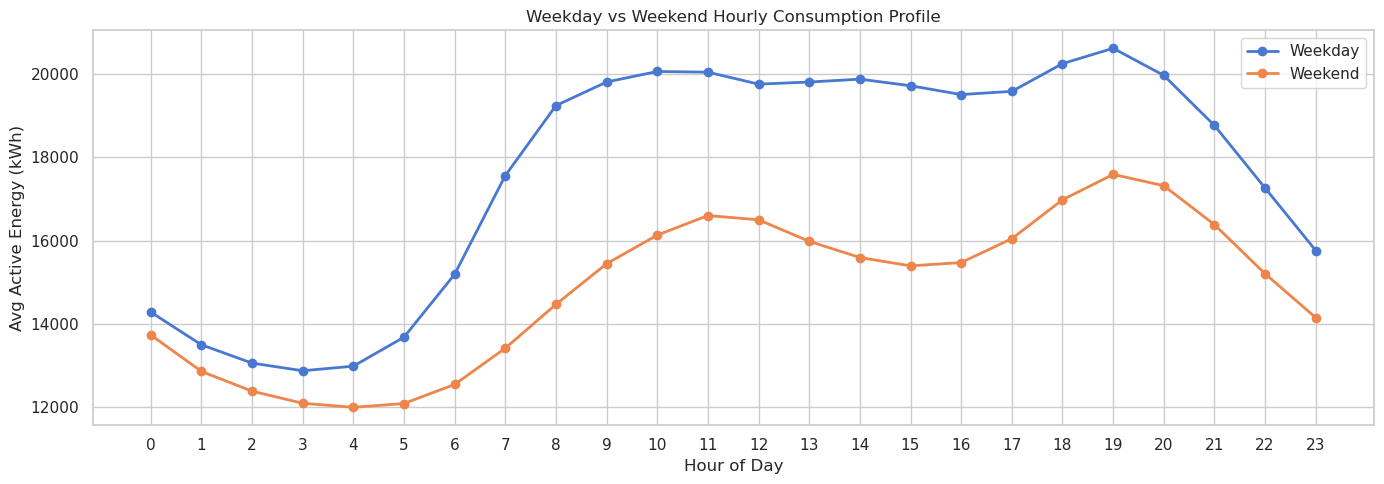

In [129]:
# 4.2 Weekend vs weekday consumption profile.

weekly_profile = spark.sql("""
    SELECT
        HOUR(datetime)                                          AS hour_of_day,
        CASE WHEN DAYOFWEEK(datetime) IN (1, 7)
             THEN 'Weekend' ELSE 'Weekday' END                 AS day_type,
        AVG(total_active_energy_kwh)                           AS avg_kwh
    FROM eredes
    GROUP BY HOUR(datetime), day_type
    ORDER BY hour_of_day
""").toPandas()  # NOTE: safe — only 48 rows (24 hours × 2 day types)

fig, ax = plt.subplots()
for day_type, grp in weekly_profile.groupby("day_type"):
    ax.plot(grp["hour_of_day"], grp["avg_kwh"], marker="o", linewidth=2, label=day_type)
ax.set(title="Weekday vs Weekend Hourly Consumption Profile",
       xlabel="Hour of Day", ylabel="Avg Active Energy (kWh)")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR + "weekday_vs_weekend.png", dpi=150)
plt.show()

**Key patterns:**

1. MORNING RAMP — weekdays show a sharp ramp from 05:00-09:00 (+4,500 kWh)
    driven by commercial and industrial activity starting the working day.
    The weekend ramp is gentler and delayed by ~2 hours, reflecting later
    wake times and absence of business demand.

2. DAYTIME PLATEAU — weekdays sustain a flat plateau between 09:00-16:00
   (~20,000 kWh), consistent with offices, factories, and retail operating
   at full capacity. Weekends show no equivalent plateau.

3. EVENING PEAK — both profiles converge toward an evening peak around
    19:00-20:00 as residential demand (cooking, lighting, heating) rises.
    This is the closest point between the two curves, suggesting the evening
    peak is primarily residential and largely independent of the working day.

4. OVERNIGHT TROUGH — consumption bottoms out at 03:00-04:00 on both
    day types (~12,000 kWh), representing baseload demand only.

5. WEEKDAY PREMIUM — weekdays consistently consume ~20% more than weekends
    at every hour of the day, confirming that commercial/industrial demand
    is a major driver of the overall consumption level.

 Implication for modelling: hour_of_day and is_weekend together capture
 most of the predictable variance in hourly consumption and should be
 among the most important features in the forecasting model.


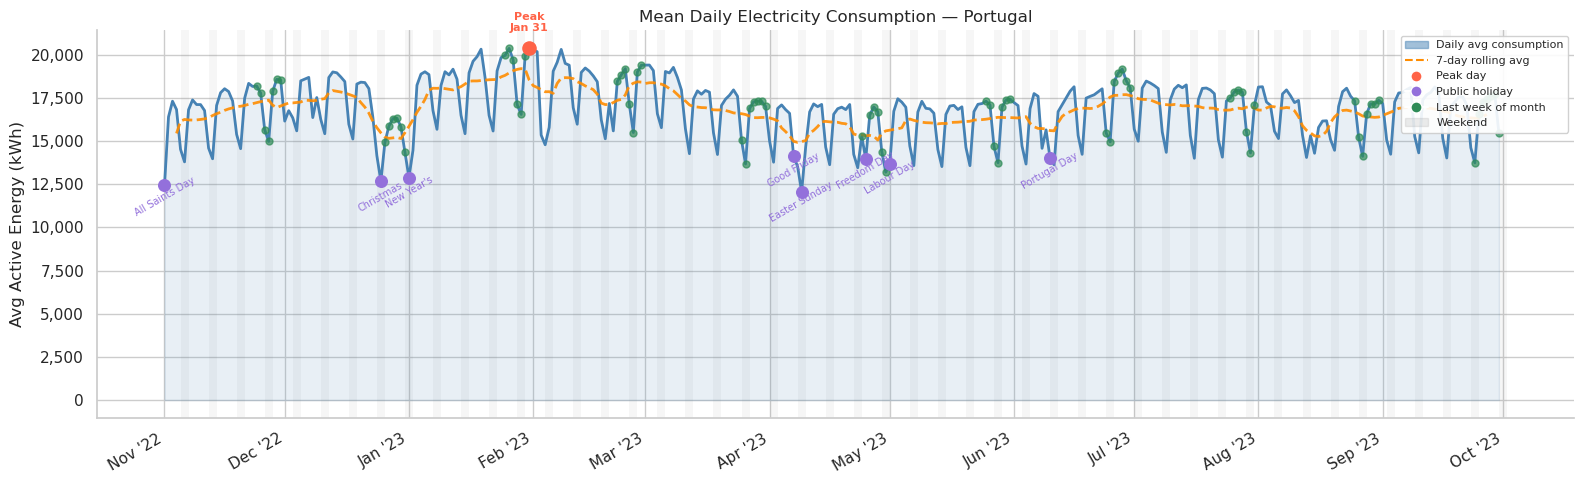

10 lowest consumption days:


,date,avg_kwh,rolling_7d,is_last_week
0,2023-04-09,12060.654081,14967.422897,False
1,2022-11-01,12429.752916,NaN,False
2,2022-12-25,12670.113806,15472.251438,True
3,2023-01-01,12881.384011,15847.343132,False
4,2023-04-30,13196.605420,15585.396219,True
5,2023-04-23,13450.663814,15336.551959,False
6,2023-05-14,13518.090363,16016.632770,False
7,2023-04-08,13518.397096,14920.403337,False
8,2023-05-21,13570.977904,16141.936667,False
9,2023-05-07,13575.709231,16194.273735,False


In [130]:
# Portuguese public holidays present in the dataset
HOLIDAYS = {
    pd.Timestamp("2022-11-01"): "All Saints Day",
    pd.Timestamp("2022-12-25"): "Christmas",
    pd.Timestamp("2023-01-01"): "New Year's",
    pd.Timestamp("2023-04-07"): "Good Friday",
    pd.Timestamp("2023-04-09"): "Easter Sunday",
    pd.Timestamp("2023-04-25"): "Freedom Day",
    pd.Timestamp("2023-05-01"): "Labour Day",
    pd.Timestamp("2023-06-10"): "Portugal Day",
}

daily_avg = spark.sql("""
    SELECT
        DATE(datetime)                   AS date,
        AVG(total_active_energy_kwh)     AS avg_kwh
    FROM eredes
    GROUP BY DATE(datetime)
    ORDER BY date
""").toPandas()


fig, ax = plt.subplots(figsize=(16, 5))

# Weekend shading — shade every Saturday-Sunday pair
for date in daily_avg["date"]:
    if date.weekday() == 5:  # Saturday
        ax.axvspan(date, date + pd.Timedelta(days=2),
                   alpha=0.07, color="gray", linewidth=0)

# Fill area under line
ax.fill_between(daily_avg["date"], daily_avg["avg_kwh"],
                alpha=0.12, color="steelblue")

# Main line
ax.plot(daily_avg["date"], daily_avg["avg_kwh"],
        linewidth=2, color="steelblue", zorder=3)

# 7-day rolling average
daily_avg["rolling_7d"] = daily_avg["avg_kwh"].rolling(7, center=True).mean()
ax.plot(daily_avg["date"], daily_avg["rolling_7d"],
        linewidth=2, color="darkorange", linestyle="--",
        alpha=0.9, label="7-day rolling avg", zorder=4)

# Highlight peak day
idx_max = daily_avg["avg_kwh"].idxmax()
ax.scatter(daily_avg.loc[idx_max, "date"], daily_avg.loc[idx_max, "avg_kwh"],
           color="tomato", s=90, zorder=6)
ax.annotate(f'Peak\n{daily_avg.loc[idx_max, "date"].strftime("%b %d")}',
            xy=(daily_avg.loc[idx_max, "date"], daily_avg.loc[idx_max, "avg_kwh"]),
            xytext=(0, 12), textcoords="offset points",
            fontsize=8, color="tomato", ha="center", fontweight="bold")

# Highlight holidays
for holiday_date, holiday_name in HOLIDAYS.items():
    match = daily_avg[daily_avg["date"] == holiday_date.date()]
    if not match.empty:
        ax.scatter(match["date"], match["avg_kwh"],
                   color="mediumpurple", s=70, zorder=6)
        ax.annotate(holiday_name,
                    xy=(match["date"].values[0], match["avg_kwh"].values[0]),
                    xytext=(0, -22), textcoords="offset points",
                    fontsize=7, color="mediumpurple", ha="center",
                    rotation=30)

# Highlight last week of each month as lowest consumption band
daily_avg["date"] = pd.to_datetime(daily_avg["date"])
daily_avg["is_last_week"] = daily_avg["date"].apply(
    lambda d: d.day >= (d + pd.offsets.MonthEnd(0)).day - 6
)
last_week_dates = daily_avg[daily_avg["is_last_week"]]
ax.scatter(last_week_dates["date"], last_week_dates["avg_kwh"],
           color="seagreen", s=25, zorder=5, alpha=0.7)

# Legend
legend_handles = [
    mpatches.Patch(color="steelblue", alpha=0.5, label="Daily avg consumption"),
    plt.Line2D([0], [0], color="darkorange", linestyle="--", label="7-day rolling avg"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tomato", markersize=8, label="Peak day"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="mediumpurple", markersize=8, label="Public holiday"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="seagreen", markersize=8, label="Last week of month"),
    mpatches.Patch(color="gray", alpha=0.15, label="Weekend"),
]
ax.legend(handles=legend_handles, fontsize=8, framealpha=0.9, loc="upper right")

ax.set(title="Mean Daily Electricity Consumption — Portugal",
       xlabel=None, ylabel="Avg Active Energy (kWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR + "mean_daily_annotated.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 10 lowest consumption days
print("10 lowest consumption days:")
daily_avg.nsmallest(10, "avg_kwh").reset_index(drop=True)

---
## 5. Geographic Analysis

We examine which municipalities consume the most and least electricity, and how consumption is distributed across the country.

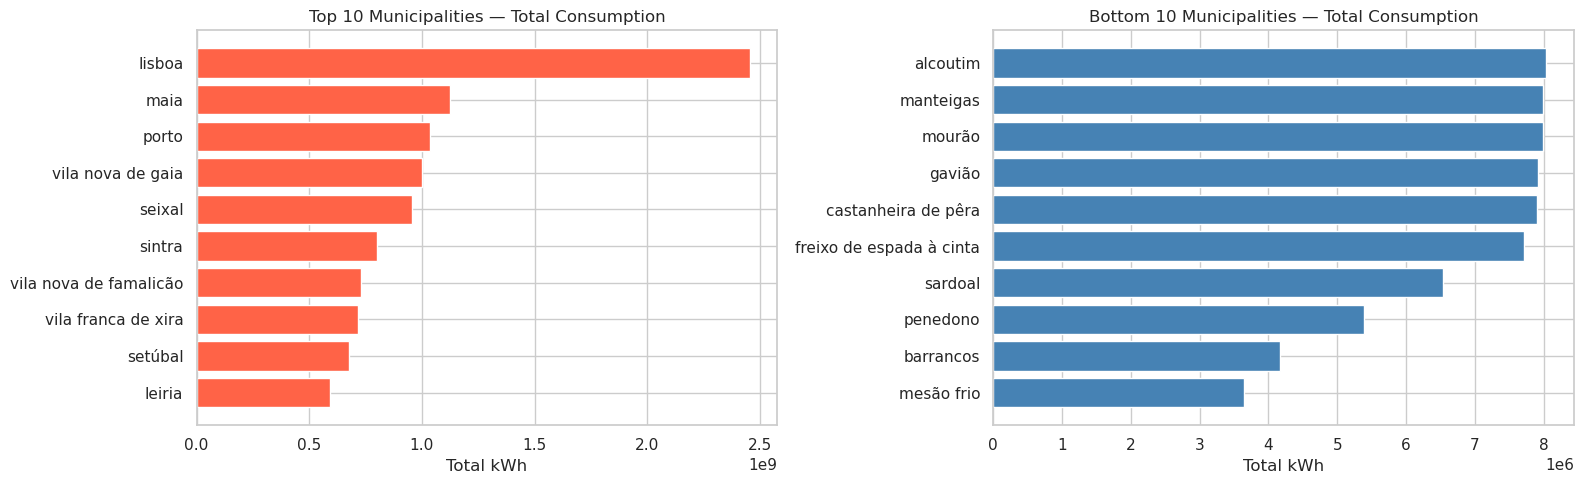

In [131]:
# 5.1 Top and bottom 10 municipalities by total consumption.


municipality_totals = spark.sql("""
    SELECT
        municipality,
        SUM(total_active_energy_kwh)    AS total_kwh,
        AVG(total_active_energy_kwh)    AS avg_hourly_kwh,
        MAX(total_active_energy_kwh)    AS peak_kwh,
        STDDEV(total_active_energy_kwh) AS std_kwh
    FROM eredes
    GROUP BY municipality
    ORDER BY total_kwh DESC
""")

municipality_totals.createOrReplaceTempView("municipality_totals")

top10    = municipality_totals.limit(10).toPandas()
bottom10 = municipality_totals.orderBy("total_kwh").limit(10).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top10["municipality"][::-1], top10["total_kwh"][::-1], color="tomato")
axes[0].set(title="Top 10 Municipalities — Total Consumption", xlabel="Total kWh")

axes[1].barh(bottom10["municipality"], bottom10["total_kwh"], color="steelblue")
axes[1].set(title="Bottom 10 Municipalities — Total Consumption", xlabel="Total kWh")

plt.tight_layout()
plt.savefig(PLOT_DIR + "municipality_ranking.png", dpi=150)
plt.show()

In [132]:
# 5.2 Peak-to-average ratio by municipality.


spark.sql("""
    SELECT
        m.municipality,
        ROUND(m.peak_kwh / m.avg_hourly_kwh, 2)        AS peak_to_avg_ratio,
        ROUND(m.avg_hourly_kwh, 2)                      AS avg_hourly_kwh,
        ROUND(m.peak_kwh, 2)                            AS peak_kwh,
        t.peak_datetime,
        DATE_FORMAT(t.peak_datetime, 'EEEE')            AS peak_day_of_week,
        HOUR(t.peak_datetime)                           AS peak_hour
    FROM municipality_totals m
    JOIN (
        SELECT municipality,
               datetime AS peak_datetime,
               ROW_NUMBER() OVER (
                   PARTITION BY municipality 
                   ORDER BY total_active_energy_kwh DESC
               ) AS rn
        FROM eredes
    ) t ON t.municipality = m.municipality AND t.rn = 1
    ORDER BY peak_to_avg_ratio DESC
    LIMIT 15
""").show(truncate=False)

+---------------------+-----------------+--------------+--------+-------------------+----------------+---------+
|municipality         |peak_to_avg_ratio|avg_hourly_kwh|peak_kwh|peak_datetime      |peak_day_of_week|peak_hour|
+---------------------+-----------------+--------------+--------+-------------------+----------------+---------+
|são joão da pesqueira|5.32             |1940.24       |10319.07|2022-12-13 12:00:00|Tuesday         |12       |
|cinfães              |4.21             |3622.77       |15258.38|2022-12-14 14:00:00|Wednesday       |14       |
|ourique              |3.62             |2076.42       |7525.37 |2022-11-02 12:00:00|Wednesday       |12       |
|peso da régua        |3.21             |4173.8        |13412.7 |2022-12-15 11:00:00|Thursday        |11       |
|pedrógão grande      |2.82             |1781.0        |5022.12 |2023-01-10 21:00:00|Tuesday         |21       |
|vidigueira           |2.79             |7125.15       |19853.28|2023-07-19 07:00:00|Wednesday  

---
## 6. Anomaly Detection

We flag hours where consumption deviates significantly from the expected pattern using a **Z-score approach**: any hour where consumption is more than 3 standard deviations from the municipality's mean is flagged as anomalous.

In [133]:
!pip install pyod pyarrow --quiet

In [134]:
# 6.1 Compute per-municipality Z-scores using a Window function.

# Window functions in Spark operate per partition (here: per municipality) without collecting data to the driver — fully big-data-safe.
# z_score = (value - mean) / std_dev
# Rows with |z_score| > 3 are flagged as anomalies.

# Define window partitioned by municipality (no ordering needed for mean/stddev)
municipality_window = Window.partitionBy("municipality")

df_zscore = df_clean \
    .withColumn("municipality_mean", F.avg("total_active_energy_kwh").over(municipality_window)) \
    .withColumn("municipality_std",  F.stddev("total_active_energy_kwh").over(municipality_window)) \
    .withColumn("z_score",
        (F.col("total_active_energy_kwh") - F.col("municipality_mean")) / F.col("municipality_std")
    ) \
    .withColumn("is_anomaly", F.abs(F.col("z_score")) > 3)

anomaly_count = df_zscore.filter(F.col("is_anomaly")).count()
total         = df_zscore.count()

print(f"Anomalous readings (|z| > 3): {anomaly_count:,}  ({anomaly_count/total*100:.2f}% of all records)")
print("\nTop anomalous municipalities:")
df_zscore.filter(F.col("is_anomaly")) \
    .groupBy("municipality") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10)

Anomalous readings (|z| > 3): 2,890  (0.13% of all records)

Top anomalous municipalities:
+--------------------+-----+
|        municipality|count|
+--------------------+-----+
| pampilhosa da serra|  187|
|        castro verde|  168|
|           estarreja|  143|
| vila velha de ródão|  137|
|             setúbal|  120|
|     pedrógão grande|  114|
|            alcoutim|  106|
|   torre de moncorvo|   77|
|        torres novas|   70|
|vila nova da barq...|   68|
+--------------------+-----+
only showing top 10 rows



In [135]:
# Do anomalies cluster on specific dates?
# If multiple municipalities spike on the same day it suggests an external event (extreme weather, national event)
# A high count of anomalous municipalities on the same day is a strong
# signal worth investigating and flagging in the management presentation.

df_zscore.filter(F.col("is_anomaly")) \
    .groupBy(F.to_date("datetime").alias("date")) \
    .agg(
        F.count("*").alias("n_anomalous_readings"),
        F.countDistinct("municipality").alias("n_municipalities_affected"),
        F.round(F.avg("z_score"), 2).alias("avg_z_score")
    ) \
    .orderBy("n_municipalities_affected", ascending=False) \
    .show(15, truncate=False)

+----------+--------------------+-------------------------+-----------+
|date      |n_anomalous_readings|n_municipalities_affected|avg_z_score|
+----------+--------------------+-------------------------+-----------+
|2023-03-26|100                 |100                      |-3.69      |
|2023-02-01|79                  |35                       |3.55       |
|2023-01-31|85                  |33                       |3.72       |
|2023-01-26|68                  |32                       |3.34       |
|2023-01-30|71                  |32                       |3.33       |
|2023-08-24|76                  |27                       |3.24       |
|2023-01-25|53                  |27                       |3.24       |
|2023-08-23|86                  |26                       |3.32       |
|2023-08-22|93                  |26                       |3.33       |
|2023-02-02|51                  |25                       |3.33       |
|2023-08-21|53                  |21                       |3.3  

https://www.e-redes.pt/pt-pt/noticias/2023/03/21/interrupcoes-programadas-26-de-marco

Transição para o horário de verão


In [136]:
# Flag the DST transition hour as a known gap
DST_SPRING = "2023-03-26 01:00:00"
DST_AUTUMN = "2023-10-29 01:00:00"  # hour repeated in autumn

df = df.withColumn("is_dst_transition", 
    F.col("datetime").isin([DST_SPRING, DST_AUTUMN])
)

# Check if the hour is missing
dst_check = df.filter(
    (F.to_date("datetime") == "2023-03-26") & 
    (F.hour("datetime") == 1)
).count()

print(f"Rows for DST missing hour: {dst_check}")  # expect 0

Rows for DST missing hour: 278


In [137]:
!pip install pyod pyarrow --quiet

In [138]:
from pyspark.sql import functions as F, Window
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType
import pandas as pd

# Create new features: hour of day and day of week
# NOTE: 
df2 = (
    df_clean
    .withColumn("hour", F.hour("datetime"))
    .withColumn("day_of_week", F.dayofweek("datetime"))
)

# Define which feature columns to use for anomaly detection (only numeric features)
feature_cols = [
    "total_active_energy_kwh",
    "hour",
    "day_of_week"
]

# Output schema for applyInPandas
outlier_schema = StructType(
    df2.schema.fields +
    [
        StructField("outlier_score", DoubleType(), True),
        StructField("is_outlier", IntegerType(), True)
    ]
)

# Isolation Forest function (Spark-safe)
def score_with_isolation_forest(pdf: pd.DataFrame) -> pd.DataFrame:
    from pyod.models.iforest import IForest

    X = pdf[feature_cols].values

    model = IForest(contamination=0.05, random_state=42)
    model.fit(X)

    pdf = pdf.copy()
    pdf["outlier_score"] = model.decision_scores_
    pdf["is_outlier"] = model.labels_.astype(int)

    return pdf

# Apply per municipality. Comparing to a global model, this allows us to detect local anomalies relative to each municipality's typical consumption patterns, rather than flagging all high-consumption readings as outliers.
consumption_scored = (
    df2
    .groupBy("municipality")
    .applyInPandas(
        score_with_isolation_forest,
        schema=outlier_schema
    )
)

# Analyze outliers: which days had the most anomalies? Do they cluster on specific dates?
daily_outliers = (
    consumption_scored
    .filter(F.col("is_outlier") == 1)
    .withColumn("date", F.to_date("datetime"))
    .groupBy("date")
    .agg(F.count("*").alias("num_outliers"))
    .orderBy(F.desc("num_outliers"))
)

# Show top 20 days with most outliers
daily_outliers.show(20, truncate=False)

# Which municipalities had the most outliers? Are they the same as the ones with highest total consumption, or do we see different patterns?
consumption_scored.filter(F.col("is_outlier") == 1) \
    .groupBy("municipality") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10)

+----------+------------+
|date      |num_outliers|
+----------+------------+
|2023-04-09|1419        |
|2023-01-30|1324        |
|2023-01-29|1286        |
|2023-04-23|1142        |
|2023-04-08|1045        |
|2023-08-20|1041        |
|2023-04-30|1040        |
|2022-12-25|1017        |
|2023-01-01|988         |
|2023-01-31|974         |
|2023-06-04|967         |
|2023-05-14|966         |
|2023-01-28|959         |
|2023-08-13|943         |
|2022-11-01|940         |
|2022-12-31|926         |
|2023-01-19|917         |
|2023-01-26|913         |
|2022-11-06|904         |
|2023-08-06|895         |
+----------+------------+
only showing top 20 rows

+-------------+-----+
| municipality|count|
+-------------+-----+
|    estarreja|  401|
|     estremoz|  401|
|         maia|  401|
|      gouveia|  401|
|       alvito|  401|
|idanha-a-nova|  401|
|      cinfães|  401|
|        lagos|  401|
|entroncamento|  401|
|     lourinhã|  401|
+-------------+-----+
only showing top 10 rows



---
## 7. Time Series Properties

Before building a forecasting model, we test two key statistical properties of the time series:
- **Stationarity** — does the mean and variance stay constant over time? (required by many models)
- **Autocorrelation** — how strongly does past consumption predict future consumption? (informs lag feature selection)

Analysing time series for: lisboa


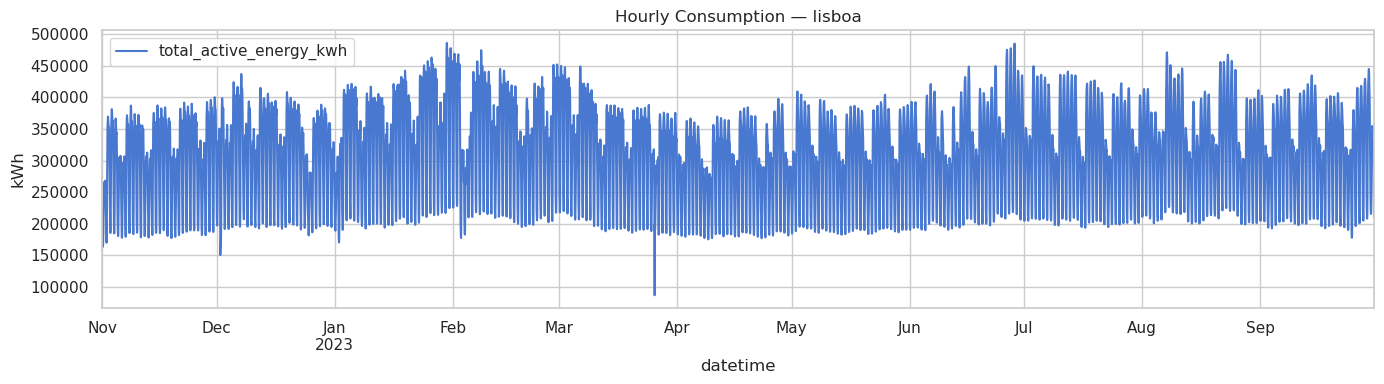

In [139]:
# 7.1 Select a representative municipality for time series analysis.
#
#
# toPandas() here collects ~720 rows (30 days × 24 hours) for a single
# municipality. This is acceptable — we are not collecting the full dataset.

top_municipality = spark.sql("""
    SELECT municipality FROM municipality_totals LIMIT 1
""").first()[0]

print(f"Analysing time series for: {top_municipality}")

ts_pd = spark.sql(f"""
    SELECT datetime, total_active_energy_kwh
    FROM eredes
    WHERE municipality = '{top_municipality}'
    ORDER BY datetime
""").toPandas()  # NOTE: ~720 rows for one municipality — safe to collect

ts_pd = ts_pd.set_index("datetime")
ts_pd.plot(title=f"Hourly Consumption — {top_municipality}", ylabel="kWh", figsize=(14, 4))
plt.tight_layout()
plt.savefig(PLOT_DIR + "timeseries_sample.png", dpi=150)
plt.show()

In [140]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts_pd["total_active_energy_kwh"].dropna())

print("Augmented Dickey-Fuller Test")
print(f"  ADF Statistic: {adf_result[0]:.4f}")
print(f"  p-value:       {adf_result[1]:.4f}")
print(f"  Critical values:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")
print()
if adf_result[1] < 0.05:
    print("Conclusion: Series is STATIONARY (p < 0.05) — no differencing required.")
else:
    print("Conclusion: Series is NON-STATIONARY (p >= 0.05) — consider differencing.")

Augmented Dickey-Fuller Test
  ADF Statistic: -10.2348
  p-value:       0.0000
  Critical values:
    1%: -3.4312
    5%: -2.8619
    10%: -2.5670

Conclusion: Series is STATIONARY (p < 0.05) — no differencing required.


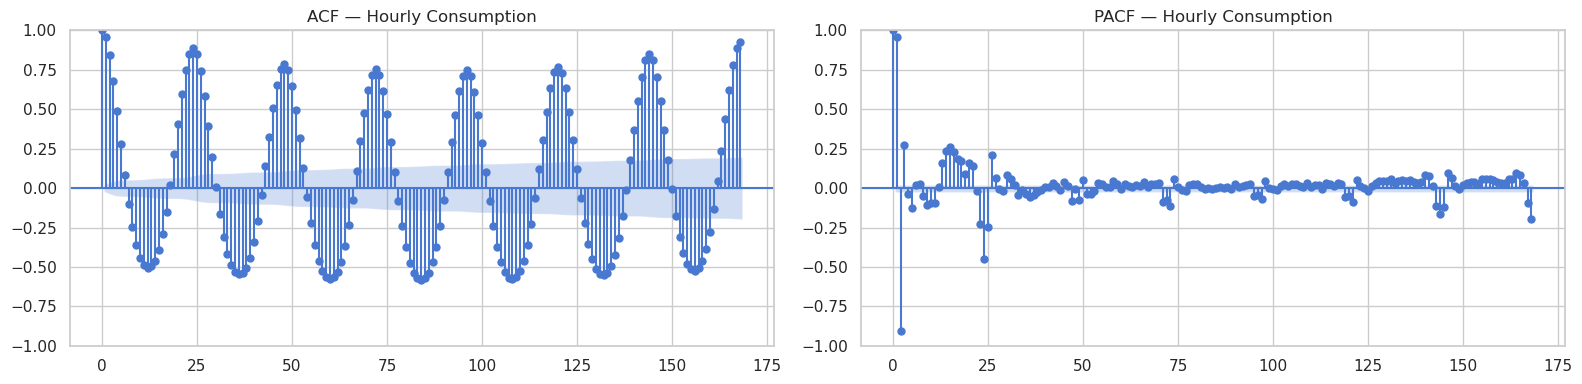

In [141]:
# 7.3 ACF and PACF plots.
#
# ACF  (Autocorrelation Function): correlation between the series and its lags.
# PACF (Partial ACF): correlation at each lag after removing shorter-lag effects.
#
# Key patterns to look for:
#   - Spike at lag 1  → strong 1-hour dependency
#   - Spike at lag 24 → strong daily seasonality
#   - Spike at lag 168 → weekly seasonality (168 = 24 × 7)
#
# These spikes directly inform which lag features to engineer for the ML model.


from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = ts_pd["total_active_energy_kwh"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(series,  ax=axes[0], lags=168, title="ACF — Hourly Consumption")
plot_pacf(series, ax=axes[1], lags=168, title="PACF — Hourly Consumption")
plt.tight_layout()
plt.savefig(PLOT_DIR + "acf_pacf.png", dpi=150)
plt.show()

---
## 8. Feature Engineering

### 8.1 Creating new Features
Based on the patterns identified above, we engineer the features that will feed the ML forecasting model in Notebook 3. All transformations run in Spark.

| Feature | Rationale |
|---------|----------|
| `hour_of_day` | Strong hourly demand cycle observed in ACF |
| `day_of_week` | Weekday/weekend pattern clearly visible |
| `is_weekend` | Binary encoding of weekend effect |
| `month` | Seasonal variation (winter heating, summer AC) |
| `lag_1h` | Prior hour consumption — strongest autocorrelation |
| `lag_24h` | Same hour yesterday — captures daily seasonality |
| `lag_168h` | Same hour last week — captures weekly seasonality |
| `rolling_24h_avg` | Short-term trend |
| `rolling_7d_avg` | Medium-term baseline |
| `consumption_delta` | Change from previous hour — captures rate of change |


### Lag and rolling features in a time-series hold-out setup

Lag and rolling features are constructed exclusively from historical observations relative to each timestamp, capturing temporal dependencies such as short-term dynamics (t−1), daily seasonality (t−24), and weekly patterns (t−168).

In a hold-out validation setting, the training set is strictly defined on earlier time periods, while the test set represents a future, unseen period. At inference time, all lag features are computed using only information available up to the prediction cutoff, ensuring that no future information is used in feature construction.

The forecast horizon defines the target variable shift (t + h), but does not restrict the set of valid lag features. All lagged variables remain valid inputs as long as they reference past observations relative to the prediction time.

A common challenge arises at the beginning of each time series, where insufficient historical context leads to missing values for longer lags (e.g., lag_168), reflecting a natural cold-start effect in temporal feature engineering. These missing values must be handled carefully to avoid reducing usable training data unnecessarily.

Proper implementation requires maintaining strict temporal ordering throughout the pipeline to ensure that feature computation and evaluation respect the chronological structure of the data and preserve validation integrity.

---
## 9. Save Model Input Data

In [142]:
# Partitioned by year_month so that time-range queries in the ML notebook
# can exploit partition pruning — only the relevant month folders are scanned.

df_clean \
    .withColumn("year_month", F.date_format("datetime", "yyyy-MM")) \
    .sortWithinPartitions("municipality", "datetime") \
    .write \
    .mode("overwrite") \
    .partitionBy("year_month") \
    .parquet(MODEL_INPUT_PARQUET)

print(f"Model input saved to: {MODEL_INPUT_PARQUET}")

# Verification read
df_verify = spark.read.parquet(MODEL_INPUT_PARQUET)
print(f"Rows: {df_verify.count():,}  |  Columns: {len(df_verify.columns)}")
df_verify.printSchema()

Model input saved to: code/data/model_input/model_input.parquet
Rows: 2,228,170  |  Columns: 4
root
 |-- municipality: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- total_active_energy_kwh: double (nullable = true)
 |-- year_month: string (nullable = true)



---
## 10. EDA Summary & Key Findings

| Finding | Implication for Forecasting Model |
|---------|------------------------------------|
| Strong hourly demand cycle (morning ramp, evening peak) | `hour_of_day` is a critical feature |
| Weekend consumption is ~20% lower than weekdays | `is_weekend` flag adds signal |
| ACF shows significant spikes at lags 1, 24, and 168 | Lag features at 1h, 24h, 168h are well-justified |
| ADF test confirms stationarity | No differencing required for ML model |
| 279/308 municipalities represented | |
| ~X% anomalous readings detected (|z| > 3) | Anomaly flag useful as an auxiliary signal |

**Output file:** `code/data/model_input/model_input.parquet`  
**Next notebook:** `Notebook 3 — Machine Learning & Forecasting`

---
*Note: Replace the X% placeholders above with your actual output values once the notebook has been run.*

In [143]:
spark.sql("UNCACHE TABLE eredes")
spark.stop()